## Phase 0 Environment Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device in use: {DEVICE}")
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected -- training will run on CPU (slower, still functional).")


Device in use: cuda
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets accelerate evaluate scikit-learn pdfplumber
!pip uninstall -y torchvision -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 101.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.3.0 which is incompatible.


In [3]:
import os

WORK_DIR = "/kaggle/working"
CHECKPOINT_DIR = f"{WORK_DIR}/qwen_classifier"
FINAL_MODEL_DIR = f"{WORK_DIR}/detector_final"
RESULTS_DIR = f"{WORK_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

INPUT_DIR = "/kaggle/input/datasets/nikhileswarkomati/suicide-watch"
assert os.path.isdir(INPUT_DIR), (
    f"Dataset folder not found at {INPUT_DIR}. "
    "Add the 'suicide-watch' dataset via the 'Add Input' panel before running this cell."
)
print("Files available in input directory:", os.listdir(INPUT_DIR))


Files available in input directory: ['Suicide_Detection.csv']


## Phase 1 Data Loading and Cleaning

In [4]:
import pandas as pd
import re
import gc

csv_candidates = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".csv")]
assert csv_candidates, f"No CSV file found in {INPUT_DIR}."
CSV_PATH = os.path.join(INPUT_DIR, csv_candidates[0])
print("Using dataset file:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
df = df[['text', 'class']].dropna()
df['label'] = df['class'].map({'suicide': 1, 'non-suicide': 0})
df = df[['text', 'label']].dropna(subset=['label'])
df['label'] = df['label'].astype(int)

def clean_text(t):
    t = re.sub(r'http\S+', '', t)
    t = re.sub(r'\[deleted\]|\[removed\]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['text'] = df['text'].astype(str).apply(clean_text)
df = df[df['text'].str.len() > 5]

print("Dataset shape after cleaning:", df.shape)
print(df['label'].value_counts())


Using dataset file: /kaggle/input/datasets/nikhileswarkomati/suicide-watch/Suicide_Detection.csv
Dataset shape after cleaning: (232059, 2)
label
0    116030
1    116029
Name: count, dtype: int64


In [ ]:
def normalize_for_dedup(t):
    t = t.lower()
    t = re.sub(r'[^a-z0-9\s]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    return t

df['_dedup_key'] = df['text'].apply(normalize_for_dedup)
n_before = len(df)
df = df.drop_duplicates(subset='_dedup_key').drop(columns=['_dedup_key'])
print(f"Rows removed as duplicates/near-duplicates: {n_before - len(df)}")
print("Final shape:", df.shape)

df.to_csv(f"{WORK_DIR}/cleaned_data.csv", index=False)


Rows removed as duplicates/near-duplicates: 236
Final shape: (231823, 2)


In [6]:
print(df['label'].value_counts(normalize=True))
print(df['text'].str.split().str.len().describe())


label
1    0.500373
0    0.499627
Name: proportion, dtype: float64
count    231823.000000
mean        131.957299
std         217.505925
min           1.000000
25%          26.000000
50%          60.000000
75%         155.000000
max        9684.000000
Name: text, dtype: float64


## Phase 2 Train/Validation/Test Split

In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

MAX_TRAIN_SIZE, MAX_VAL_SIZE = 20000, 2500
if len(train_df) > MAX_TRAIN_SIZE:
    train_df, _ = train_test_split(train_df, train_size=MAX_TRAIN_SIZE, stratify=train_df['label'], random_state=42)
if len(val_df) > MAX_VAL_SIZE:
    val_df, _ = train_test_split(val_df, train_size=MAX_VAL_SIZE, stratify=val_df['label'], random_state=42)

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

del df, temp_df
gc.collect()


Train: 20000 | Val: 2500 | Test: 23183


38

## Phase 3 Model: Qwen2.5-0.5B (full fine-tuning)

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL_NAME = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    dtype=torch.float32,
)
model.config.pad_token_id = tokenizer.pad_token_id
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,} (full fine-tuning, all trainable)")


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters: 494,034,560 (full fine-tuning, all trainable)


## Phase 4 Tokenization

In [9]:
from datasets import Dataset

MAX_LENGTH = 128

def tokenize_fn(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=MAX_LENGTH)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tokenize_fn, batched=True)
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True)).map(tokenize_fn, batched=True)
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True)).map(tokenize_fn, batched=True)

cols = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

del train_df, val_df
gc.collect()


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/23183 [00:00<?, ? examples/s]

59

## Phase 5 Training with Class-Weighted Loss

In [10]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

train_labels = train_ds['label'].numpy() if hasattr(train_ds['label'], 'numpy') else np.array(train_ds['label'])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights (0=non-suicide, 1=suicide):", class_weights)


Class weights (0=non-suicide, 1=suicide): [1.00070049 0.99930049]


In [11]:
from transformers import Trainer, TrainingArguments
import torch.nn as nn

class WeightedTrainer(Trainer):
    """Standard Trainer with a class-weighted CrossEntropyLoss to address label imbalance."""
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, 2), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


In [12]:
import evaluate

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1": f1_metric.compute(predictions=preds, references=labels)["f1"],
        "precision": precision_metric.compute(predictions=preds, references=labels)["precision"],
        "recall": recall_metric.compute(predictions=preds, references=labels)["recall"],
    }


In [ ]:
on_gpu = (DEVICE == "cuda")

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,               
    learning_rate=2e-5,
    per_device_train_batch_size=8 if on_gpu else 4,
    per_device_eval_batch_size=16 if on_gpu else 8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=on_gpu,
    dataloader_pin_memory=False,
    dataloader_num_workers=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss", 
    greater_is_better=False,           
    logging_steps=50,
    report_to="none",
    seed=42,
)

from transformers import EarlyStoppingCallback

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print(f"Training configured for: {'GPU' if on_gpu else 'CPU'}")

Training configured for: GPU


In [14]:
def find_latest_valid_checkpoint(ckpt_dir):
    """Returns the most recent COMPLETE checkpoint, skipping any that were only partially
    written (e.g. due to an interrupted session), identified by the presence of
    trainer_state.json which is only written once a checkpoint save has finished."""
    if not os.path.isdir(ckpt_dir):
        return None
    candidates = [d for d in os.listdir(ckpt_dir) if d.startswith("checkpoint-")]
    valid = [
        c for c in candidates
        if os.path.isfile(os.path.join(ckpt_dir, c, "trainer_state.json"))
        and os.path.isfile(os.path.join(ckpt_dir, c, "model.safetensors"))
    ]
    if not valid:
        return None
    valid.sort(key=lambda x: int(x.split("-")[1]))
    return os.path.join(ckpt_dir, valid[-1])

last_checkpoint = find_latest_valid_checkpoint(CHECKPOINT_DIR)

try:
    if last_checkpoint:
        print(f"Resuming from checkpoint: {last_checkpoint}")
        trainer.train(resume_from_checkpoint=last_checkpoint)
    else:
        print("No valid checkpoint found -- starting training from scratch.")
        trainer.train()
except torch.cuda.OutOfMemoryError:
    print("CUDA out of memory. Reduce per_device_train_batch_size and/or MAX_TRAIN_SIZE, "
          "then restart the session and re-run from Phase 0.")
    raise

No valid checkpoint found -- starting training from scratch.


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
200,0.207844,0.128375,0.978800,0.978758,0.981511,0.976019
400,0.203313,0.088757,0.970800,0.970045,0.996627,0.944844
600,0.154909,0.082487,0.983200,0.983078,0.991064,0.975220
800,0.040805,0.106361,0.984000,0.983897,0.991079,0.976819
1000,0.050490,0.072053,0.986000,0.985983,0.987961,0.984013
1200,0.036226,0.099747,0.984000,0.984102,0.978656,0.989608
1400,0.000014,0.092102,0.989200,0.989178,0.991961,0.986411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
model.save_pretrained(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)
print(f"Final model saved to: {FINAL_MODEL_DIR}")
print("Remember to click 'Save Version' to persist this output, "
      "then download 'detector_final/' from the Output tab.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final model saved to: /kaggle/working/detector_final
Remember to click 'Save Version' to persist this output, then download 'detector_final/' from the Output tab.


## Phase 6 Evaluation and Decision Threshold Tuning

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import torch.nn.functional as F
import json as jsonlib

preds_output = trainer.predict(test_ds)
y_true = np.array(test_ds['label'])
y_prob = F.softmax(torch.tensor(preds_output.predictions), dim=1)[:, 1].numpy()

print("=== Default threshold (0.5) ===")
y_pred_default = (y_prob >= 0.5).astype(int)
print(classification_report(y_true, y_pred_default, target_names=['non-suicide', 'suicide']))
print("ROC-AUC:", roc_auc_score(y_true, y_prob))


=== Default threshold (0.5) ===
              precision    recall  f1-score   support

 non-suicide       0.98      0.99      0.99     11583
     suicide       0.99      0.98      0.99     11600

    accuracy                           0.99     23183
   macro avg       0.99      0.99      0.99     23183
weighted avg       0.99      0.99      0.99     23183

ROC-AUC: 0.9986759169948826


In [ ]:
MIN_PRECISION = 0.97   

prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
valid_idx = [i for i in range(len(thresholds)) if prec[i] >= MIN_PRECISION]
if valid_idx:
    best_idx = max(valid_idx, key=lambda i: rec[i])
    OPTIMAL_THRESHOLD = float(thresholds[best_idx])
    print(f"Selected threshold: {OPTIMAL_THRESHOLD:.3f} (precision={prec[best_idx]:.3f}, recall={rec[best_idx]:.3f})")
else:
    OPTIMAL_THRESHOLD = 0.5
    print("No threshold reaches the target precision -- falling back to 0.5. Consider revisiting MIN_PRECISION.")

y_pred_tuned = (y_prob >= OPTIMAL_THRESHOLD).astype(int)
print("\n=== Tuned threshold ===")
print(classification_report(y_true, y_pred_tuned, target_names=['non-suicide', 'suicide']))


Selected threshold: 0.012 (precision=0.970, recall=0.992)

=== Tuned threshold ===
              precision    recall  f1-score   support

 non-suicide       0.99      0.97      0.98     11583
     suicide       0.97      0.99      0.98     11600

    accuracy                           0.98     23183
   macro avg       0.98      0.98      0.98     23183
weighted avg       0.98      0.98      0.98     23183



In [18]:
cm = confusion_matrix(y_true, y_pred_tuned)
report_text = classification_report(y_true, y_pred_tuned, target_names=['non-suicide', 'suicide'])

with open(f"{RESULTS_DIR}/classification_report.txt", "w") as f:
    f.write(report_text)

pd.DataFrame(
    cm, index=['true_non-suicide', 'true_suicide'], columns=['pred_non-suicide', 'pred_suicide']
).to_csv(f"{RESULTS_DIR}/confusion_matrix.csv")

metrics_summary = {
    "threshold_used": OPTIMAL_THRESHOLD,
    "accuracy": float((y_pred_tuned == y_true).mean()),
    "roc_auc": float(roc_auc_score(y_true, y_prob)),
    "confusion_matrix": cm.tolist(),
    "model": MODEL_NAME,
    "train_size": int(len(train_ds)),
    "val_size": int(len(val_ds)),
    "test_size": int(len(test_ds)),
}
with open(f"{RESULTS_DIR}/metrics_summary.json", "w") as f:
    jsonlib.dump(metrics_summary, f, indent=2)

print("Results saved to:", RESULTS_DIR)


Results saved to: /kaggle/working/results


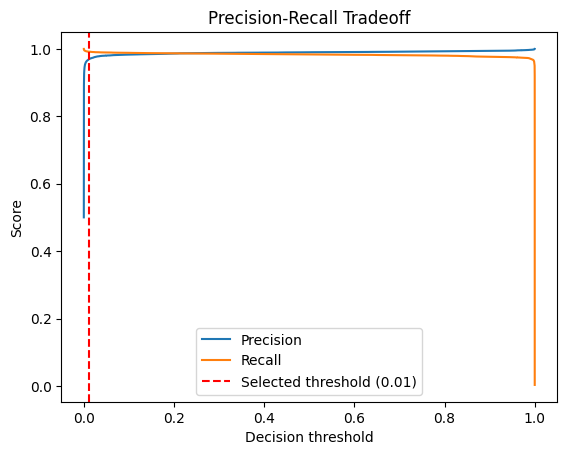

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, prec[:-1], label='Precision')
plt.plot(thresholds, rec[:-1], label='Recall')
plt.axvline(OPTIMAL_THRESHOLD, color='red', linestyle='--', label=f'Selected threshold ({OPTIMAL_THRESHOLD:.2f})')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.savefig(f"{RESULTS_DIR}/pr_tradeoff.png")
plt.show()


## Phase 7 Baseline Comparison (TF-IDF + Logistic Regression)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

train_df_full = pd.read_csv(f"{WORK_DIR}/cleaned_data.csv")
train_texts_for_baseline, _ = train_test_split(
    train_df_full, test_size=0.2, stratify=train_df_full['label'], random_state=42
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_texts_for_baseline['text'])

test_texts = pd.DataFrame({'text': [tokenizer.decode(t, skip_special_tokens=True) for t in test_ds['input_ids']]})

baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_model.fit(X_train, train_texts_for_baseline['label'])
print("Baseline trained. Compare its classification_report against the fine-tuned model's above.")


Baseline trained. Compare its classification_report against the fine-tuned model's above.


## Phase 8 Error Analysis

In [21]:
test_texts_decoded = [tokenizer.decode(t, skip_special_tokens=True) for t in test_ds['input_ids']]
analysis_df = pd.DataFrame({
    'text': test_texts_decoded,
    'label': y_true,
    'pred': y_pred_tuned,
    'prob': y_prob,
})

false_negatives = analysis_df[(analysis_df['label'] == 1) & (analysis_df['pred'] == 0)]
false_positives = analysis_df[(analysis_df['label'] == 0) & (analysis_df['pred'] == 1)]

print(f"False negatives: {len(false_negatives)} | False positives: {len(false_positives)}")
print("\n=== Sample false negatives (highest-priority to review) ===")
print(false_negatives[['text', 'prob']].head(10))
print("\n=== Sample false positives ===")
print(false_positives[['text', 'prob']].head(10))

analysis_df.to_csv(f"{RESULTS_DIR}/test_predictions.csv", index=False)


False negatives: 95 | False positives: 355

=== Sample false negatives (highest-priority to review) ===
                                                   text      prob
249   Just gotta say it feels good...... to be so fu...  0.000610
2139                                           Sorry :/  0.010288
2280  Anyone want to chat? I see people coming in an...  0.000032
2551  I dont know what to do... First of I live with...  0.000048
2824  depressedprobrobly puberty, but i accidently m...  0.001496
2944  Dangers of an exit bag Has anyone survived an ...  0.000064
3028  How much can I tell my therapist without getti...  0.000171
3080  Love, what an evil and unfair feeling. I start...  0.000387
3106  A list of my insecurities. 18 Female.Why I am ...  0.000734
3155  I'll listen to Aphex Twin's song"Rhubarb" and ...  0.000767

=== Sample false positives ===
                                                  text      prob
55   It's hot, I'm feeling hot, my mind is in flame...  0.093323
174  i j